In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import os
from scipy.interpolate import make_interp_spline 

In [2]:
# Ask user for file path
file_path = input("Enter full path to Excel file: ").strip()
if not os.path.exists(file_path):
    print("File not found. Check the path and try again.")
    

Enter full path to Excel file:  F:/Users/kanak/Desktop/Kanak_Data/CRPP/Optical Microscope/20260424/DwSA_CalciumBath.xlsx


In [3]:
#Load Excel file
excel_file = pd.ExcelFile(file_path)

print("\nAvailable sheets:")
for i, sheet in enumerate(excel_file.sheet_names):
    print(f"{i}: {sheet}")

sheet_index = int(input("\nEnter sheet number: "))
sheet_name = excel_file.sheet_names[sheet_index]

df = pd.read_excel(file_path, sheet_name=sheet_name)

print("\nAvailable columns:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")



Available sheets:
0: DwSA_CalciumBath



Enter sheet number:  0



Available columns:
0:  
1: Area
2: Mean
3: StdDev
4: Min
5: Max
6: Feret
7: FeretX
8: FeretY
9: FeretAngle
10: MinFeret


In [4]:
# Select columns
#x_index = int(input("\nEnter column number for X: "))
y_index = int(input("Enter column number for Y (used for histogram): "))

#x_col = df.columns[x_index]
y_col = df.columns[y_index]

#x_data = df[x_col].dropna()
y_data = df[y_col].dropna()

Enter column number for Y (used for histogram):  6


In [5]:
data = y_data.dropna()

print("----- DATA SUMMARY -----")
print("Count :", len(data))
print("Min   :", data.min())
print("Max   :", data.max())
print("Mean  :", data.mean())
print("Std   :", data.std())

----- DATA SUMMARY -----
Count : 57
Min   : 256.465
Max   : 294.935
Mean  : 274.7998771929824
Std   : 8.138363208704309


In [6]:
#User inputs for binning
bin_min = float(input("Enter starting value: "))
bin_max = float(input("Enter ending value: "))
bin_width = float(input("Enter interval: "))

Enter starting value:  256
Enter ending value:  295
Enter interval:  5


In [7]:
# Create bins
bins = np.arange(bin_min, bin_max + bin_width, bin_width)

#Histogram
counts, bin_edges = np.histogram(data, bins=bins)

#Create labels
labels = [
    f"{int(bin_edges[i])}-{int(bin_edges[i+1])}"
    for i in range(len(bin_edges) - 1)
]

#Create table
table = pd.DataFrame({
    "Label": labels,
    "Bin": bin_edges[1:],   # upper edge like Excel
    "Count": counts
})

print("\nFrequency Table:\n")
print(table)


Frequency Table:

     Label    Bin  Count
0  256-261  261.0      2
1  261-266  266.0      6
2  266-271  271.0     11
3  271-276  276.0     16
4  276-281  281.0     10
5  281-286  286.0      8
6  286-291  291.0      1
7  291-296  296.0      3


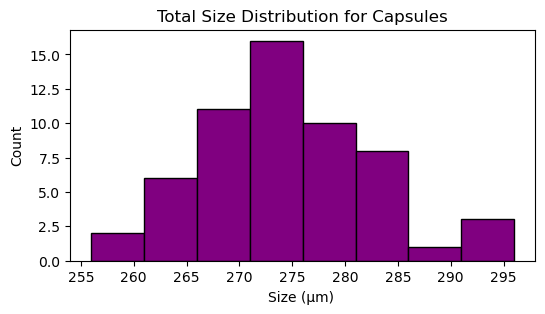

In [8]:
#Plot Size Distribution Histogram
plt.figure(figsize=(6,3))

plt.bar(
    bin_edges[:-1],     # left edges
    counts,             # frequencies
    width=np.diff(bin_edges),  # bin width
    align='edge',
    edgecolor='black',
    color='purple'
)

plt.xlabel("Size (µm) ")
plt.ylabel("Count")
plt.title("Total Size Distribution for Capsules")

plt.show()

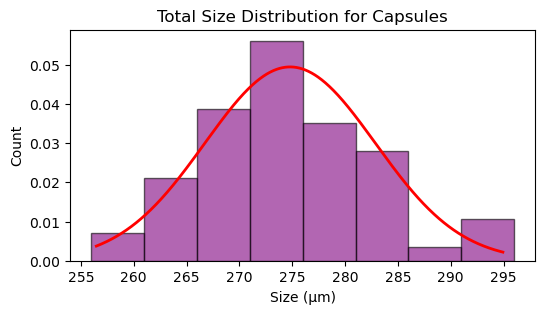

In [10]:
# Calculate mean and standard deviation
mean = np.mean(data)
std_dev = np.std(data)

# Smooth x values
x = np.linspace(min(data), max(data), 1000)

# Normal PDF
y = norm.pdf(x, mean, std_dev)

# Plot
plt.figure(figsize=(6,3))

# Histogram normalized to density
plt.hist(
    data,
    bins=bins,
    density=True,
    color='purple',
    edgecolor='black',
    alpha=0.6,
    label='Histogram'
)

# Normal distribution curve
plt.plot(
    x,
    y,
    color='red',
    linewidth=2,
    label='Normal Distribution'
)


#Text on Graph for Mean Size
#plt.text(
   # 0.45, 0.9,
  #  f"Mean Size = {data.mean():.2f} ± {data.std():.2f} µm",
   # transform=plt.gca().transAxes,
   # fontsize=12,
    #bbox=dict(facecolor='white', alpha=0.7)
#)

plt.xlabel("Size (µm)")
plt.ylabel("Count")
plt.title("Total Size Distribution for Capsules")

#plt.legend()
#plt.grid(True)

plt.show()

In [123]:
#Computation for Core Size of Capsule
#Ask User Again to Select the Sheet
#Load Excel file 
excel_file = pd.ExcelFile(file_path)

print("\nAvailable sheets:")
for i, sheet in enumerate(excel_file.sheet_names):
    print(f"{i}: {sheet}")

sheet_index = int(input("\nEnter sheet number: "))
sheet_name = excel_file.sheet_names[sheet_index]

df = pd.read_excel(file_path, sheet_name=sheet_name)

print("\nAvailable columns:")
for i, col in enumerate(df.columns):
    print(f"{i}: {col}")


Available sheets:
0: Total
1: Core



Enter sheet number:  1



Available columns:
0:  
1: Area
2: Mean
3: StdDev
4: Min
5: Max
6: Feret
7: FeretX
8: FeretY
9: FeretAngle
10: MinFeret


In [124]:
# Select columns
#x_index = int(input("\nEnter column number for X: "))
y_index = int(input("Enter column number for Y (used for histogram): "))

x_col = df.columns[x_index]
y_col = df.columns[y_index]

x_data = df[x_col].dropna()
y_data = df[y_col].dropna()

Enter column number for Y (used for histogram):  6


In [125]:
data = y_data.dropna()

print("----- DATA SUMMARY -----")
print("Count :", len(data))
print("Min   :", data.min())
print("Max   :", data.max())
print("Mean  :", data.mean())
print("Std   :", data.std())

----- DATA SUMMARY -----
Count : 12
Min   : 228.172
Max   : 250.005
Mean  : 240.256
Std   : 6.9542849053985805


In [127]:
## User inputs for binning
bin_min = float(input("Enter starting value: "))
bin_max = float(input("Enter ending value: "))
bin_width = float(input("Enter interval: "))

Enter starting value:  228
Enter ending value:  250
Enter interval:  5


In [128]:
# Create bins
bins = np.arange(bin_min, bin_max + bin_width, bin_width)

#Histogram
counts, bin_edges = np.histogram(data, bins=bins)

#Create labels
labels = [
    f"{int(bin_edges[i])}-{int(bin_edges[i+1])}"
    for i in range(len(bin_edges) - 1)
]

#Create table
table = pd.DataFrame({
    "Label": labels,
    "Bin": bin_edges[1:],   # upper edge like Excel
    "Count": counts
})

print("\nFrequency Table:\n")
print(table)


Frequency Table:

     Label    Bin  Count
0  228-233  233.0      2
1  233-238  238.0      2
2  238-243  243.0      2
3  243-248  248.0      5
4  248-253  253.0      1


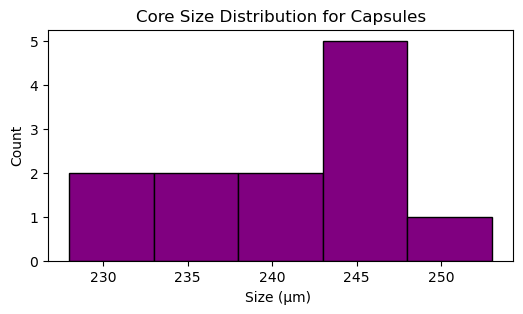

In [129]:
#Plot Size Distribution Histogram
plt.figure(figsize=(6,3))

plt.bar(
    bin_edges[:-1],     # left edges
    counts,             # frequencies
    width=np.diff(bin_edges),  # bin width
    align='edge',
    edgecolor='black',
    color='purple'
)

plt.xlabel("Size (µm) ")
plt.ylabel("Count")
plt.title("Core Size Distribution for Capsules")

plt.show()

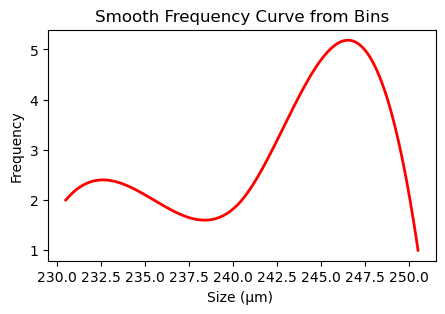

In [130]:
#Plot Smooth Lin Bin Graph
# bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

#smooth curve
x_smooth = np.linspace(bin_centers.min(), bin_centers.max(), 300)

spline = make_interp_spline(bin_centers, counts, k=3)
y_smooth = spline(x_smooth)

#plot
plt.figure(figsize=(5,3))

plt.plot(x_smooth, y_smooth, color='red', linewidth=2)

plt.xlabel("Size (µm) ")
plt.ylabel("Frequency")
plt.title("Smooth Frequency Curve from Bins")
plt.show()

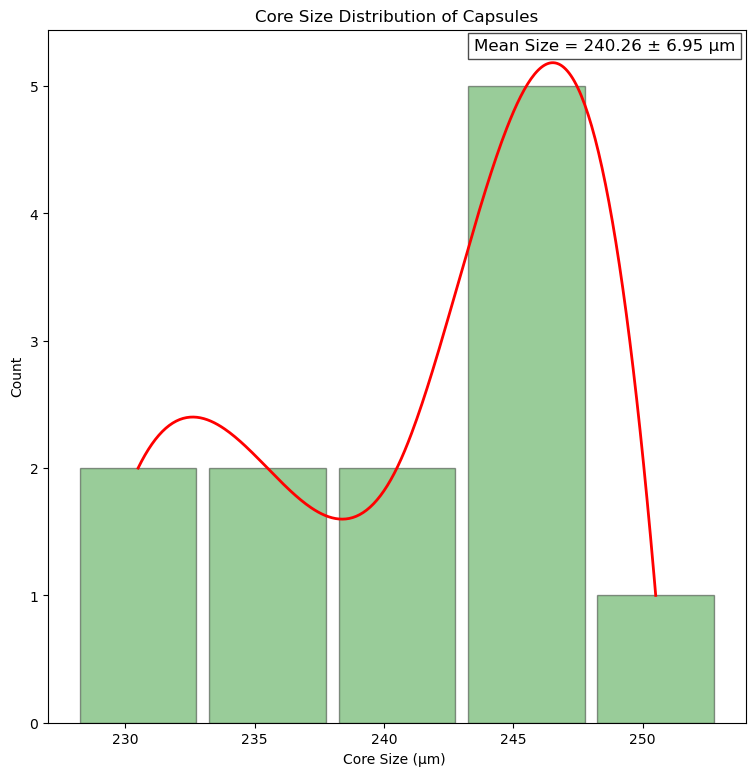

In [131]:
#Plot Both Graphs Together
plt.figure(figsize=(9,9)) #size of figure

# Histogram (bars)
plt.bar(
    bin_centers,
    counts,
    width=bin_width * 0.9,
    alpha=0.4,
    edgecolor='black',
    color='green',
    label='Histogram'
)

# Smooth line
plt.plot(
    x_smooth,
    y_smooth,
    color='red',
    linewidth=2,
    label='Smooth Curve'
)

#Text on Graph for Mean Size
plt.text(
    0.61, 0.97,
    f"Mean Size = {data.mean():.2f} ± {data.std():.2f} µm",
    transform=plt.gca().transAxes,
    fontsize=12,
    bbox=dict(facecolor='white', alpha=0.7)
)

#Plot Graph
plt.xlabel("Core Size (µm) ")
plt.ylabel("Count")
plt.title("Core Size Distribution of Capsules")
#plt.grid(alpha=0.3)
#plt.legend()

plt.show()